# DAAAnalyzer_1.0.AnalyzeDPOAEs.ipynb
Created by: JFranco | Created On: 26 NOV 2024 | Last Env: QISHA | Last Run Date: 26 NOV 2024

This Python notebook will read in all DPOAE files for a specific DAA Run as specified by the user. It will make a lineplot for all availble files and label them by category. 

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import xlrd
import math
import matplotlib.pyplot as plt

In [54]:
#                *** WHAT TO ANALYZE // WHERE TO GET/STORE **
# Key identifiers
prepID = 'CMI_003'
daaRun = '1'
daaType = 'Pre-Noise Exposure'
isoFile = 'IsoDP-'+daaRun+'-1.tsv'
fnMD = 'CMI_003.Metadata.AnimalInfo.csv'

# Directories 
#   existing ones 
dirMain = '/Users/joyfranco/Dropbox (Partners HealthCare)/JF_Shared/Data/CFTS/'
dirPrep = dirMain+prepID+'/'
dirData = dirPrep+'RawData/'
dirMD = dirPrep+'Metadata/'

#   ones that need to be made    
dirSV = dirPrep+'Results/'        

In [29]:
# Parameters for plotting
conditions = ["HABclw","CtrlInj","UnInj"]
pltOrder = conditions
colors = {pltOrder[0]:'goldenrod' , pltOrder[1]:'slateblue', pltOrder[2]:'mediumorchid'}
legColors = ["goldenrod", "slateblue","mediumorchid"]

In [30]:
#    *** LOAD MD SHEETS **
# Sample metadata sheet that include animal and condition info
dfMD = pd.read_csv(dirMD+fnMD)
dfMD.reset_index(inplace=True)
dfMD

,index,AnimalID,Sex,DOB,CMIID,InjectionDate,AgeAtInjection,Package,InjGroup,NE,NEDate,AgeAtNE,NELevel,NEBand,NEDuration,NEGroup
0,0,C016,M,9/24/24,CMI_003,11/11/24,7,AAV,HABclw,Yes,11/25/24,9,97.5,8_16,2h,1
1,1,C017,F,9/24/24,CMI_003,11/11/24,7,AAV,HABclw,Yes,11/25/24,9,97.5,8_16,2h,2
2,2,C018,M,9/24/24,CMI_003,11/11/24,7,AAV,HABclw,Yes,11/25/24,9,97.5,8_16,2h,2
3,3,C019,F,9/24/24,CMI_003,11/11/24,7,AAV,CtrlInj,Yes,11/25/24,9,97.5,8_16,2h,1
4,4,C020,M,9/24/24,CMI_003,11/11/24,7,AAV,CtrlInj,Yes,11/25/24,9,97.5,8_16,2h,1
5,5,C021,F,9/24/24,CMI_003,11/11/24,7,AAV,CtrlInj,Yes,11/25/24,9,97.5,8_16,2h,2
6,6,C022,M,9/24/24,CMI_003,11/11/24,7,AAV,UnInj,Yes,11/25/24,9,97.5,8_16,2h,2
7,7,C023,F,9/24/24,CMI_003,11/11/24,7,AAV,UnInj,Yes,11/25/24,9,97.5,8_16,2h,1


In [31]:
#           *** INITIALIZE RUN SPECIFIC DIRECTORY ETC FOR STORING RESULTS **
# Create directory for storing spreadsheetS and summary plotS for this run
if not os.path.exists(dirSV): os.mkdir(dirSV)

In [32]:
#           *** GENERATE A LIST OF DAA FOLDERS THAT WILL BE ANALYZED **
# Get a list of all the folders that match the prep
allData = os.listdir(dirData)
dataList = []
for datum in allData:
    if ('.'+daaRun) in datum:
        dataList.append(datum)
dataList

['CMI_003.C020.1',
 'CMI_003.C023.1',
 'CMI_003.C016.1',
 'CMI_003.C018.1',
 'CMI_003.C022.1',
 'CMI_003.C017.1',
 'CMI_003.C019.1',
 'CMI_003.C021.1']

In [42]:
#           *** READ IN EACH ISOLINE TSV FILE FOR EACH DPOAE**
# Iterate through the folders
dfAll = pd.DataFrame()
for daa in dataList:
    # Setup the path to the file
    path = dirData+daa+'/'+isoFile
    # Read in the file & make adjustments for readability
    dfIso = pd.read_csv(path,  sep='\t')
    dfIso['Vals'] = dfIso.index
    # Iterate through all of the rows available and get values 
    freqs = []
    threshs = []
    for index, row in dfIso.iterrows():
        f2Freq = row['Vals'][0]
        f2Freq = int(float(f2Freq)/1000)
        if (f2Freq != 64):
            freqs.append(f2Freq)
            thresh = row['Vals'][3]
            if thresh =='   NaN':
                thresh = 75
            threshs.append(int(float(thresh)))
    data = {'f2Freq_kHz': freqs, 'Thresh_dBSPL': threshs}
    df = pd.DataFrame(data)
    anID = daa[8:-2]
    df['AnimalID'] = anID
    df['CMIID'] = prepID
    df['DAA_Run'] = daaRun
    # Get information about this animal from the MD sheet
    inMD = dfMD.index[dfMD['AnimalID']==anID].tolist()[0]
    inj = dfMD.loc[inMD]['InjGroup']
    sex = dfMD.loc[inMD]['Sex']
    df['InjGroup'] = inj
    df['Sex'] = sex
    dfAll = pd.concat([dfAll,df])
dfAll.reset_index(inplace=True)

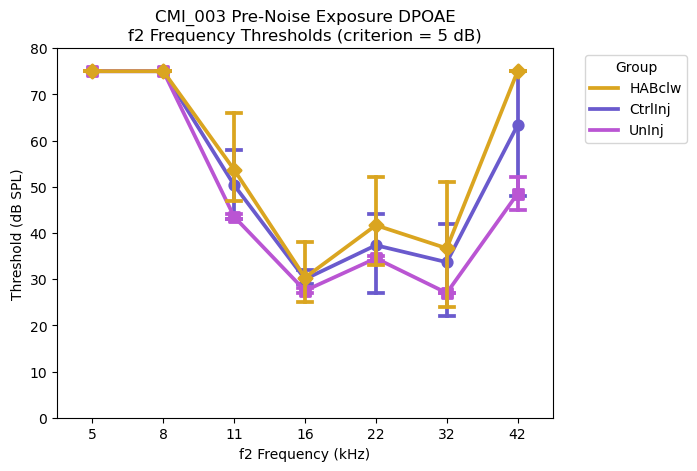

In [56]:
# *** SET PLOT SPECIFIC PARAMETERS ***
plot = "DPOAEs.DAA_"+daaRun
plottype = "PtPlt"
title = prepID+" "+daaType+" DPOAE\n"+"f2 Frequency Thresholds (criterion = 5 dB)"
hue = 'InjGroup'
x = "f2Freq_kHz"
y="Thresh_dBSPL"
xlab = "f2 Frequency (kHz)"
ylab = "Threshold (dB SPL)"
ymin = 0
ymax = 80

# *** MAKE PLOT ***
ax = sns.pointplot(data=dfAll,x=x, y=y, hue=hue,markers=["o", "s", "D"], linestyles=["-", "-","-"],
                   errorbar=("pi", 100), capsize=.2, palette=colors)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=conditions)
leg = ax.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
ax.set_title(title)
ax.set(xlabel=xlab)
ax.set(ylabel=ylab)
ax.set_ylim((ymin, ymax))

# *** SAVE THE FIGURE ***
plt.savefig(dirSV+prepID+'.'+plot+'.'+plottype+'.png',  bbox_inches='tight', dpi = 300,format = 'png')